# NeuroRes-GNN: DGL 2026 Brain Graph Super-Resolution (Spec §3.1)

Spec-compliant deliverable: 3-fold CV with anchor random seed, bar plots of 8 evaluation measures, per-fold prediction CSVs, and Kaggle submission. Primary model: **v3r_eb_ffnn_aug_light** (best config, 0.127094 Kaggle MAE with shrink 3%). Optional comparison with SGC and VGAE baselines.

## 1. Reproducibility and Setup (Spec Note 2)

Insert configurations from basiralab/DGL reproducibility.py at the beginning for deterministic results.

In [1]:
import json
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path

notebook_dir = Path('.').resolve()
repo_root = notebook_dir.parent
sys.path.insert(0, str(repo_root))

# Reproducibility config (Spec Note 2)
import reproducibility
random_seed = reproducibility.random_seed
DEVICE = reproducibility.device

import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

from src.data_utils import vec_to_adj, lr_node_features, to_tensor
from models.sgc_baseline import SGCBaseline
from models.vgae import VGAEBaseline
from utils.matrix_vectorizer import MatrixVectorizer
from utils.metrics import evaluate_fold
from utils.plotting import plot_folds, plot_folds_grouped
from src.train_dense_gcn import mixup_batch

CUDA is available. Using GPU.
Using GPU: NVIDIA GeForce RTX 4080 Laptop GPU


/home/jeet/y4/neurores-gnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Config

- **Primary model:** v3r_eb_ffnn_aug_light (best-performing NeuroRes-GNN config, Kaggle MAE 0.127094 with shrink 3%)
- **COMPARE_BASELINES:** Set to True to also run SGC and VGAE for comparison (adds runtime)

In [2]:
@dataclass
class PipelineConfig:
    """Notebook entry configuration so the full pipeline can be rerun with explicit inputs."""
    data_dir: Path
    output_dir: Path
    artifacts_dir: Path
    primary_model: str = "v3r_eb_ffnn_aug_light"
    compare_baselines: bool = True
    fresh: bool = True
    random_state: int = random_seed
    n_lr: int = 160
    n_hr: int = 268


# Default notebook config. Update these paths/flags instead of editing the pipeline code.
CONFIG = PipelineConfig(
    data_dir=repo_root / "data",
    output_dir=repo_root / "submission",
    artifacts_dir=repo_root / "artifacts" / "v3r_eb_ffnn_aug_light_shrink03",
    primary_model="v3r_eb_ffnn_aug_light",
    compare_baselines=True,
    fresh=False,
    random_state=random_seed,
)

## 2. Main Entry Function (Spec 3.1.d)

All inputs received as function parameters: train/test data and model parameters.

In [3]:
def load_csv(path: Path) -> np.ndarray:
    """Load a competition CSV (skip header row) into float32 numpy arrays."""
    arr = np.loadtxt(path, delimiter=',', skiprows=1, dtype=np.float32)
    return arr if arr.ndim > 1 else arr[None, :]


def load_dataset_triplet(data_dir: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load the train/test CSV inputs expected by the challenge notebook."""
    x_lr_train = load_csv(data_dir / 'lr_train.csv')
    y_hr_train = load_csv(data_dir / 'hr_train.csv')
    x_lr_test = load_csv(data_dir / 'lr_test.csv')
    return x_lr_train, y_hr_train, x_lr_test


def print_section(title: str) -> None:
    """Print a clear notebook section divider for long-running outputs."""
    bar = '=' * 80
    print(f"\n{bar}\n{title}\n{bar}")


def load_saved_cv_result(
    artifacts_dir: Path,
    out_dir: Path | None = None,
    submission_name: str = 'submission.csv',
) -> dict | None:
    """Load saved fold metrics from cv_summary.json and optionally copy saved CSV outputs."""
    cv_path = artifacts_dir / 'cv_summary.json'
    if not cv_path.exists():
        return None
    with open(cv_path, 'r', encoding='utf-8') as f:
        cv = json.load(f)
    fold_metrics = [r['metrics'] for r in cv['folds']]
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        for i in (1, 2, 3):
            src = artifacts_dir / f'predictions_fold_{i}.csv'
            if src.exists():
                pd.read_csv(src).to_csv(out_dir / f'predictions_fold_{i}.csv', index=False)
        sub_src = artifacts_dir / submission_name
        if sub_src.exists() and submission_name == 'submission.csv':
            pd.read_csv(sub_src).to_csv(out_dir / 'submission.csv', index=False)
    return {'fold_metrics': fold_metrics}


def run_v3r_eb_ffnn_cv(
    data_dir: Path,
    out_dir: Path,
    artifacts_dir: Path,
    preset: str = "v3r_eb_ffnn_aug_light",
    fresh: bool = True,
) -> dict:
    """Run the primary NeuroRes-GNN preset via train_dense_gcn, then copy outputs into the submission folder."""
    import json
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    out_dir.mkdir(parents=True, exist_ok=True)
    if not fresh:
        saved = load_saved_cv_result(artifacts_dir, out_dir=out_dir)
        if saved is not None:
            print_section(f'NeuroRes-GNN | Loading saved CV artifacts from {artifacts_dir.name}')
            print(f'Loading saved CV summary from {artifacts_dir}')
            plot_folds_grouped(saved['fold_metrics'], normalize_strength=True)
            return saved
    print_section(f'NeuroRes-GNN | Running CV for preset {preset}')
    cmd = [
        sys.executable,
        "-m",
        "src.train_dense_gcn",
        "cv",
        "--preset",
        preset,
        "--data-dir",
        str(data_dir),
        "--out-dir",
        str(artifacts_dir),
    ]
    if fresh:
        cmd.append("--fresh")
    print(f"Running: {' '.join(cmd)}")
    subprocess.run(cmd, check=True, cwd=str(repo_root))
    saved = load_saved_cv_result(artifacts_dir, out_dir=out_dir)
    if saved is None:
        raise FileNotFoundError(f'Missing cv_summary.json after CV run in {artifacts_dir}')
    plot_folds_grouped(saved['fold_metrics'], normalize_strength=True)
    print(f"Copied outputs to {out_dir}")
    return saved


def run_main_pipeline(config: PipelineConfig) -> dict:
    """Single notebook entrypoint: load data, run 3-fold CV, write CSVs, and optionally compare baselines."""
    x_lr_train, y_hr_train, x_lr_test = load_dataset_triplet(config.data_dir)
    print_section('Dataset Summary')
    print(
        f"Train LR: {x_lr_train.shape} | Train HR: {y_hr_train.shape} | Test LR: {x_lr_test.shape}"
    )

    results = {}
    result_v3r = run_v3r_eb_ffnn_cv(
        data_dir=config.data_dir,
        out_dir=config.output_dir,
        artifacts_dir=config.artifacts_dir,
        preset=config.primary_model,
        fresh=config.fresh,
    )
    results['NeuroRes-GNN'] = result_v3r

    if config.compare_baselines:
        comp_dir = repo_root / "artifacts" / "comparison"
        sgc_dir = comp_dir / 'sgc'
        vgae_dir = comp_dir / 'vgae'
        result_sgc = None
        result_vgae = None
        if not config.fresh:
            result_sgc = load_saved_cv_result(sgc_dir)
            result_vgae = load_saved_cv_result(vgae_dir, submission_name='submission_vgae.csv')
        if result_sgc is None:
            print_section('SGC Baseline | Running 3-fold CV')
            sgc_kw = dict(n_lr=config.n_lr, n_hr=config.n_hr, d_model=64, K=2, in_node_feat_dim=2)
            result_sgc = run_3fold_cv_sgc(
                x_lr_train,
                y_hr_train,
                x_lr_test,
                n_lr=config.n_lr,
                n_hr=config.n_hr,
                model_kwargs=sgc_kw,
                epochs=400,
                patience=60,
                lr=8e-4,
                weight_decay=1e-4,
                random_state=config.random_state,
                output_dir=sgc_dir,
                plot=True,
            )
        else:
            print_section(f'SGC Baseline | Loading saved CV artifacts from {sgc_dir.name}')
            print(f'Loading saved SGC CV summary from {sgc_dir}')
            plot_folds_grouped(result_sgc['fold_metrics'], normalize_strength=True)
        if result_vgae is None:
            print_section('VGAE Baseline | Running 3-fold CV')
            result_vgae = run_3fold_cv_vgae(
                x_lr_train,
                y_hr_train,
                x_lr_test,
                n_lr=config.n_lr,
                n_hr=config.n_hr,
                epochs=400,
                patience=60,
                lr=8e-4,
                weight_decay=1e-4,
                random_state=config.random_state,
                output_dir=vgae_dir,
                plot=True,
            )
        else:
            print_section(f'VGAE Baseline | Loading saved CV artifacts from {vgae_dir.name}')
            print(f'Loading saved VGAE CV summary from {vgae_dir}')
            plot_folds_grouped(result_vgae['fold_metrics'], normalize_strength=True)
        results['SGC baseline'] = result_sgc
        results['VGAE baseline'] = result_vgae

    return {
        'config': config,
        'x_lr_train': x_lr_train,
        'y_hr_train': y_hr_train,
        'x_lr_test': x_lr_test,
        'results': results,
        'result_v3r': results['NeuroRes-GNN'],
        'result_sgc': results.get('SGC baseline'),
        'result_vgae': results.get('VGAE baseline'),
    }


def run_3fold_cv_sgc(
    X_lr_train: np.ndarray,
    Y_hr_train: np.ndarray,
    X_lr_test: np.ndarray,
    n_lr: int = 160,
    n_hr: int = 268,
    model_kwargs: dict | None = None,
    epochs: int = 400,
    patience: int = 60,
    batch_size: int = 16,
    lr: float = 8e-4,
    weight_decay: float = 1e-4,
    mixup_alpha: float = 0.2,
    mixup_prob: float = 0.5,
    use_residual: bool = True,
    random_state: int = 42,
    output_dir: Path | str | None = None,
    plot: bool = True,
) -> dict:
    """
    Run 3-fold CV with SGC, evaluate on 8 metrics, save predictions_fold_{1,2,3}.csv,
    generate bar plots (if plot=True), and produce final submission.

    Parameters
    ----------
    X_lr_train : np.ndarray
        LR training data (167, 12720).
    Y_hr_train : np.ndarray
        HR training labels (167, 35778).
    X_lr_test : np.ndarray
        LR test data (112, 12720).
    n_lr, n_hr : int
        LR/HR node counts.
    model_kwargs : dict
        Arguments for SGCBaseline (n_lr, n_hr, d_model, K, in_node_feat_dim).
    epochs, patience, batch_size, lr, weight_decay : float/int
        Training hyperparameters.
    random_state : int
        Anchor seed for KFold (Spec Note 3).
    output_dir : Path | str
        Directory for predictions_fold_*.csv and submission.csv.

    Returns
    -------
    dict
        fold_metrics, fold_models, test_preds, ensemble.
    """
    if model_kwargs is None:
        model_kwargs = dict(n_lr=n_lr, n_hr=n_hr, d_model=64, K=2, in_node_feat_dim=2)
    else:
        model_kwargs = {**dict(n_lr=n_lr, n_hr=n_hr), **model_kwargs}

    out = Path(output_dir) if output_dir else repo_root / 'submission'
    out.mkdir(parents=True, exist_ok=True)

    # KFold with shuffle=True and random_state (Spec Note 3)
    kf = KFold(n_splits=3, shuffle=True, random_state=random_state)
    vectorizer = MatrixVectorizer()

    fold_metrics = []
    fold_models = []
    test_preds = []

    for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_lr_train), start=1):
        print(f"\n{'='*50}")
        print(f'Fold {fold_id}: train={len(tr_idx)}, val={len(va_idx)}')
        print(f"{'='*50}")

        model, y_mean = _train_one_fold(
            X_lr_train[tr_idx], Y_hr_train[tr_idx],
            X_lr_train[va_idx], Y_hr_train[va_idx],
            fold_id, model_kwargs, epochs, patience, batch_size, lr, weight_decay,
            mixup_alpha, mixup_prob, use_residual,
        )
        fold_models.append(model)

        # Evaluate on validation set (for bar plots)
        pred_vecs, gt_vecs = _predict_validation(model, X_lr_train[va_idx], Y_hr_train[va_idx], n_lr, n_hr, batch_size, y_mean)
        pred_mats = np.stack([vectorizer.anti_vectorize(v, n_hr) for v in pred_vecs])
        gt_mats = np.stack([vectorizer.anti_vectorize(v, n_hr) for v in gt_vecs])
        metrics = evaluate_fold(pred_mats, gt_mats, verbose=True)
        fold_metrics.append(metrics)

        # Test predictions from this fold's model (Spec: predictions_fold_{fold_num}.csv)
        test_pred = _predict_test(model, X_lr_test, n_lr, batch_size, y_mean)
        test_preds.append(test_pred)

        # Save predictions_fold_{fold_num}.csv in Kaggle format (Spec 3.1.1)
        _save_predictions_csv(test_pred, out / f'predictions_fold_{fold_id}.csv')
        print(f'  Saved {out / f"predictions_fold_{fold_id}.csv"}')

    # Bar plots of 8 metrics (Spec 3.1.2)
    if plot:
        plot_folds_grouped(fold_metrics, normalize_strength=True)

    # Final submission: ensemble of 3 folds, post-processed (no negatives, Spec Note 4)
    ensemble = np.clip(np.mean(test_preds, axis=0), a_min=0.0, a_max=None)
    _save_predictions_csv(ensemble, out / 'submission.csv')
    print(f'\nSaved submission: {out / "submission.csv"}')

    return {'fold_metrics': fold_metrics, 'fold_models': fold_models, 'test_preds': test_preds, 'ensemble': ensemble}


def _train_one_fold(X_tr, Y_tr, X_va, Y_va, fold_id, model_kwargs, epochs, patience, batch_size, lr, weight_decay,
                  mixup_alpha=0.2, mixup_prob=0.5, use_residual=True):
    """Train model for one fold with early stopping, LR schedule, mixup, residual (Spec §II.B: fair comparison)."""
    y_mean = Y_tr.mean(axis=0).astype(np.float32) if use_residual else None
    Ytr_centered = (Y_tr - y_mean) if y_mean is not None else Y_tr
    Yva_centered = (Y_va - y_mean) if y_mean is not None else Y_va
    Xtr = to_tensor(X_tr, DEVICE)
    Ytr = to_tensor(Ytr_centered, DEVICE)
    Xva = to_tensor(X_va, DEVICE)
    Yva = to_tensor(Yva_centered, DEVICE)
    tr_loader = DataLoader(TensorDataset(Xtr, Ytr), batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(TensorDataset(Xva, Yva), batch_size=batch_size, shuffle=False)

    n_lr = model_kwargs['n_lr']
    model = SGCBaseline(**model_kwargs).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=15, min_lr=1e-6)
    loss_fn = nn.L1Loss()

    best_val, best_state = float('inf'), None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for x_vec, y_vec in tr_loader:
            x_vec, y_vec = mixup_batch(x_vec, y_vec, mixup_alpha, mixup_prob)
            A = vec_to_adj(x_vec, n_lr)
            X = lr_node_features(A)
            loss = loss_fn(model(A, X), y_vec)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_vec, y_vec in va_loader:
                A = vec_to_adj(x_vec, n_lr)
                X = lr_node_features(A)
                val_losses.append(loss_fn(model(A, X), y_vec).item())
        val_loss = np.mean(val_losses)
        scheduler.step(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 50 == 0 or epoch == 1:
            print(f'  Fold {fold_id} | Epoch {epoch:3d}/{epochs} | Val: {val_loss:.6f}')

        if patience_counter >= patience:
            print(f'  Early stopping at epoch {epoch} (no improvement for {patience} epochs)')
            break

    model.load_state_dict(best_state)
    return model, y_mean if use_residual else None


def _predict_validation(model, X_va, Y_va, n_lr, n_hr, batch_size, y_mean=None):
    """Predict on validation set for metric evaluation. Add y_mean back if residual mode."""
    model.eval()
    loader = DataLoader(TensorDataset(to_tensor(X_va, DEVICE), to_tensor(Y_va, DEVICE)), batch_size=batch_size, shuffle=False)
    preds, gts = [], []
    with torch.no_grad():
        for x_vec, y_vec in loader:
            A = vec_to_adj(x_vec, n_lr)
            X = lr_node_features(A)
            p = model(A, X).cpu().numpy()
            if y_mean is not None:
                p = p + y_mean[np.newaxis, :]
            preds.append(p)
            gts.append(y_vec.cpu().numpy())
    return np.concatenate(preds), np.concatenate(gts)


def _predict_test(model, X_test, n_lr, batch_size, y_mean=None):
    """Predict on test set (112 subjects). Add y_mean back if residual mode."""
    model.eval()
    loader = DataLoader(TensorDataset(to_tensor(X_test, DEVICE)), batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for (x_vec,) in loader:
            A = vec_to_adj(x_vec, n_lr)
            X = lr_node_features(A)
            p = model(A, X).cpu().numpy()
            if y_mean is not None:
                p = p + y_mean[np.newaxis, :]
            preds.append(p)
    return np.concatenate(preds)


def _save_predictions_csv(preds: np.ndarray, path: Path):
    """Save predictions in Kaggle format: ID, Predicted (Spec 3.1.1)."""
    preds = np.clip(preds, a_min=0.0, a_max=None)  # No negatives (Spec Note 4)
    n_subjects, n_features = preds.shape
    ids = np.arange(1, n_subjects * n_features + 1)
    pd.DataFrame({'ID': ids, 'Predicted': preds.flatten()}).to_csv(path, index=False)


def run_3fold_cv_vgae(X_lr_train, Y_hr_train, X_lr_test, n_lr=160, n_hr=268, epochs=400, patience=60,
                      batch_size=16, lr=8e-4, weight_decay=1e-4, mixup_alpha=0.2, mixup_prob=0.5, use_residual=True,
                      random_state=42, output_dir=None, plot=True) -> dict:
    """Run 3-fold CV with VGAE baseline. Same training setup as NeuroRes-GNN (Spec §II.B: fair comparison)."""
    out = Path(output_dir) if output_dir else repo_root / "submission"
    out.mkdir(parents=True, exist_ok=True)
    kf = KFold(n_splits=3, shuffle=True, random_state=random_state)
    vectorizer = MatrixVectorizer()
    fold_metrics, test_preds = [], []
    vgae_kw = dict(n_lr=n_lr, n_hr=n_hr, hidden_dim=64, latent_dim=64, in_node_feat_dim=2, dropout=0.1)
    for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_lr_train), start=1):
        Y_tr = Y_hr_train[tr_idx]
        Y_va = Y_hr_train[va_idx]
        y_mean = Y_tr.mean(axis=0).astype(np.float32) if use_residual else None
        Ytr_centered = (Y_tr - y_mean) if y_mean is not None else Y_tr
        Yva_centered = (Y_va - y_mean) if y_mean is not None else Y_va
        model = VGAEBaseline(**vgae_kw).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=15, min_lr=1e-6)
        Xtr = to_tensor(X_lr_train[tr_idx], DEVICE)
        Ytr = to_tensor(Ytr_centered, DEVICE)
        Xva = to_tensor(X_lr_train[va_idx], DEVICE)
        Yva = to_tensor(Yva_centered, DEVICE)
        tr_loader = DataLoader(TensorDataset(Xtr, Ytr), batch_size=batch_size, shuffle=True)
        va_loader = DataLoader(TensorDataset(Xva, Yva), batch_size=batch_size, shuffle=False)
        best_val, best_state = float('inf'), None
        pc = 0
        for ep in range(1, epochs + 1):
            model.train()
            for x, y in tr_loader:
                x, y = mixup_batch(x, y, mixup_alpha, mixup_prob)
                A = vec_to_adj(x, n_lr)
                X = lr_node_features(A)
                loss = nn.L1Loss()(model(A, X), y)
                opt.zero_grad()
                loss.backward()
                opt.step()
            model.eval()
            val_losses = []
            with torch.no_grad():
                for x, y in va_loader:
                    A = vec_to_adj(x, n_lr)
                    X = lr_node_features(A)
                    val_losses.append(nn.L1Loss()(model(A, X), y).item())
            val_loss = np.mean(val_losses)
            scheduler.step(val_loss)
            if val_loss < best_val:
                best_val, best_state, pc = val_loss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
            else:
                pc += 1
            if pc >= patience:
                break
        model.load_state_dict(best_state)
        pred_vecs, gt_vecs = _predict_validation(model, X_lr_train[va_idx], Y_hr_train[va_idx], n_lr, n_hr, batch_size, y_mean)
        pred_mats = np.stack([vectorizer.anti_vectorize(v, n_hr) for v in pred_vecs])
        gt_mats = np.stack([vectorizer.anti_vectorize(v, n_hr) for v in gt_vecs])
        metrics = evaluate_fold(pred_mats, gt_mats, verbose=True)
        fold_metrics.append(metrics)
        test_pred = _predict_test(model, X_lr_test, n_lr, batch_size, y_mean)
        test_preds.append(test_pred)
        _save_predictions_csv(test_pred, out / f"predictions_fold_{fold_id}_vgae.csv")
    if plot:
        plot_folds_grouped(fold_metrics, normalize_strength=True)
    ensemble = np.clip(np.mean(test_preds, axis=0), a_min=0.0, a_max=None)
    _save_predictions_csv(ensemble, out / "submission_vgae.csv")
    return {"fold_metrics": fold_metrics, "test_preds": test_preds}

## 3. Load Data and Run (Single Run - Spec 3.1.c)

Load ALR_tr, AHR_tr (167 train), and test LR. Run 3-fold CV; outputs: predictions_fold_{1,2,3}.csv, bar plots, submission.csv.

In [4]:
# Load data from the explicit notebook config so the inputs are easy to swap.
X_lr_train, Y_hr_train, X_lr_test = load_dataset_triplet(CONFIG.data_dir)
data_dir = CONFIG.data_dir
print(f'Train LR: {X_lr_train.shape} | Train HR: {Y_hr_train.shape} | Test LR: {X_lr_test.shape}')

Train LR: (167, 12720) | Train HR: (167, 35778) | Test LR: (112, 12720)


### Best model: NeuroRes-GNN (v3r_eb_ffnn_aug_light_shrink03)

Run 3-fold CV via train_dense_gcn script. Outputs: predictions_fold_{1,2,3}.csv, submission.csv, bar plots. Best Kaggle MAE: 0.127094 (with shrink 3%).


Dataset Summary
Train LR: (167, 12720) | Train HR: (167, 35778) | Test LR: (112, 12720)

NeuroRes-GNN | Loading saved CV artifacts from v3r_eb_ffnn_aug_light_shrink03
Loading saved CV summary from /home/jeet/y4/neurores-gnn/artifacts/v3r_eb_ffnn_aug_light_shrink03
Plotting Edge prediction: ['MAE', 'PCC', 'JSD']


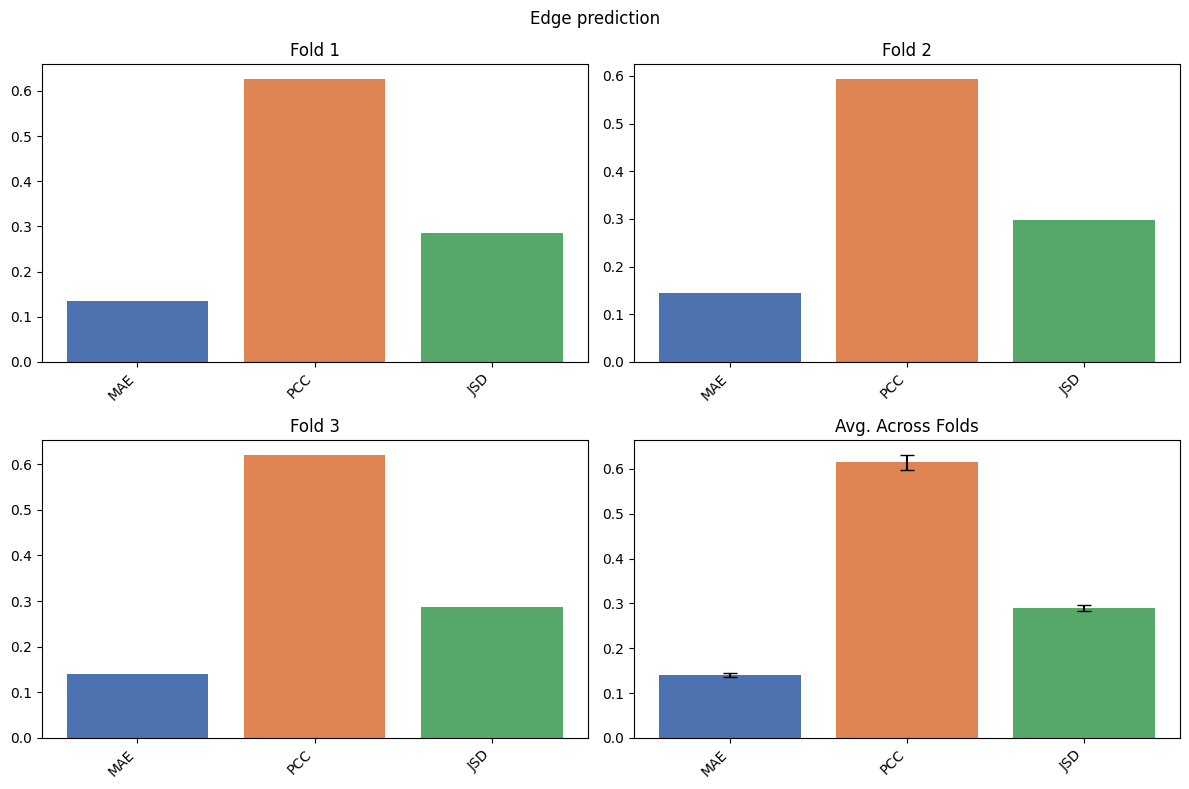

Plotting Centrality preservation: ['MAE (PC)', 'MAE (EC)', 'MAE (BC)']


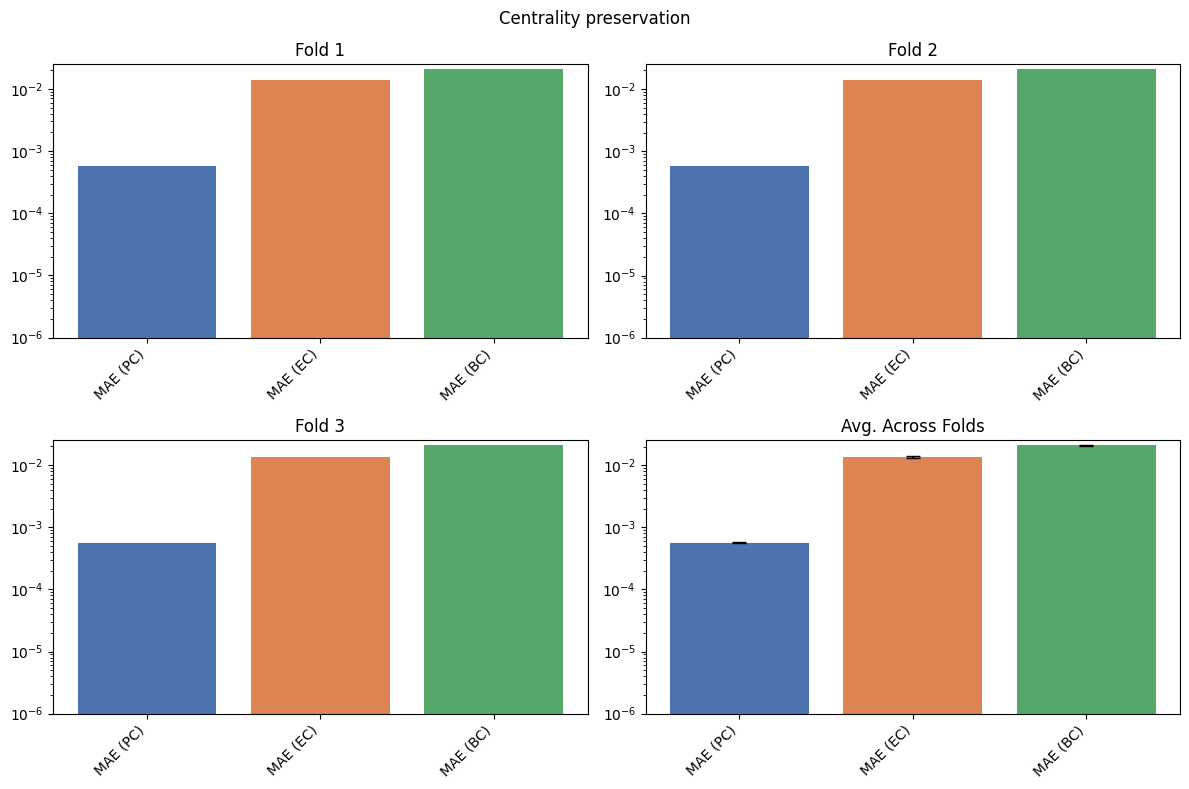

Plotting Structural topology: ['MAE (Strength)', 'MAE (Clustering)']


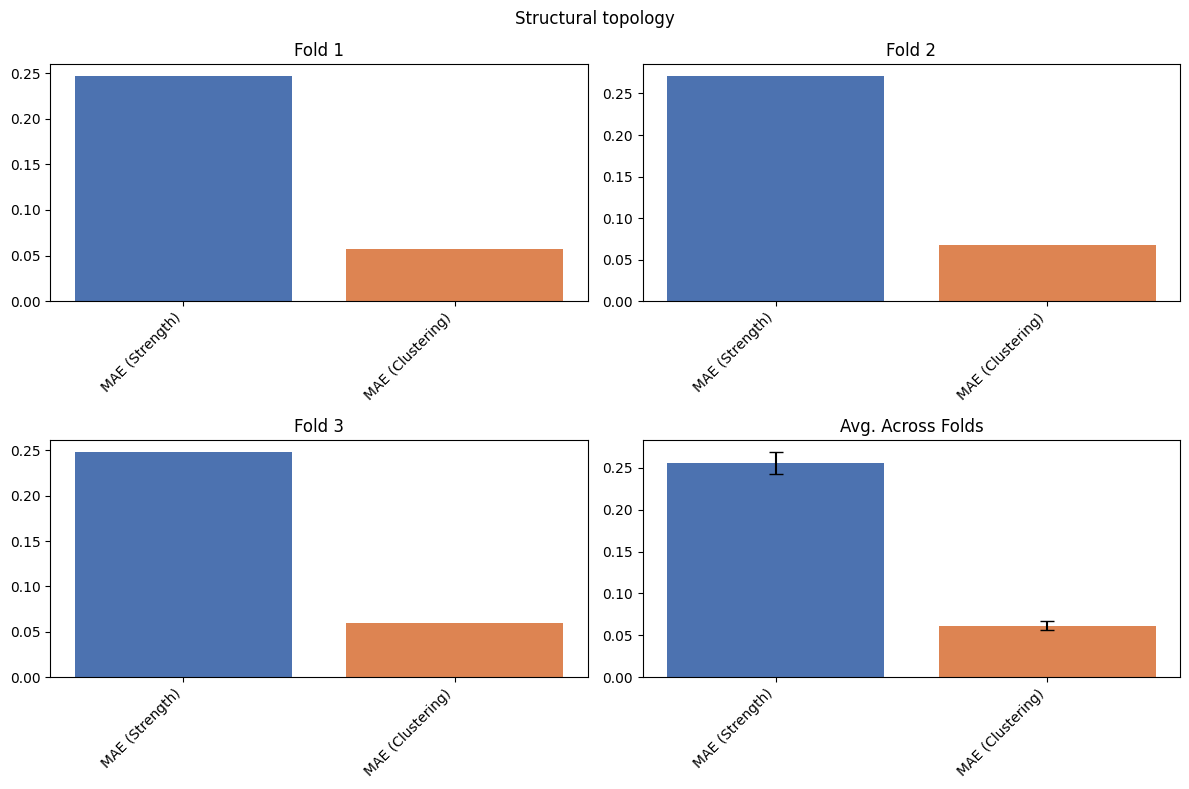


SGC Baseline | Loading saved CV artifacts from sgc
Loading saved SGC CV summary from /home/jeet/y4/neurores-gnn/artifacts/comparison/sgc
Plotting Edge prediction: ['MAE', 'PCC', 'JSD']


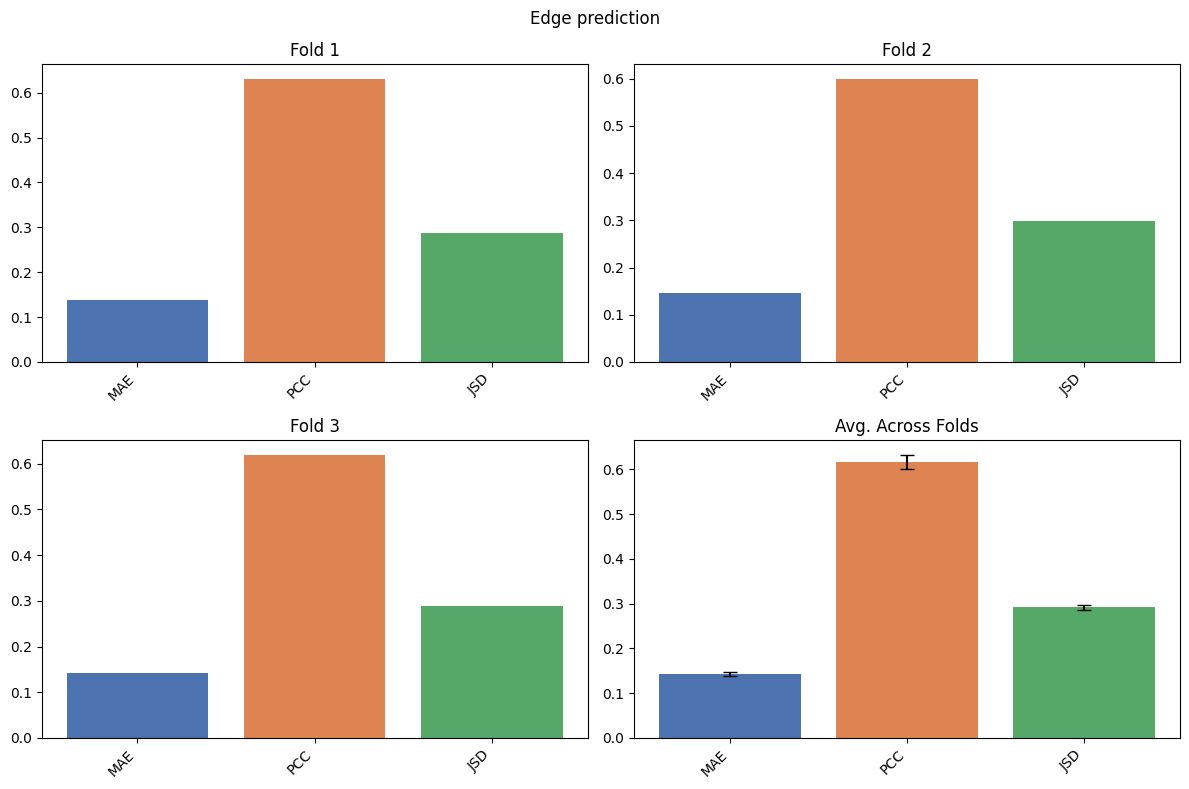

Plotting Centrality preservation: ['MAE (PC)', 'MAE (EC)', 'MAE (BC)']


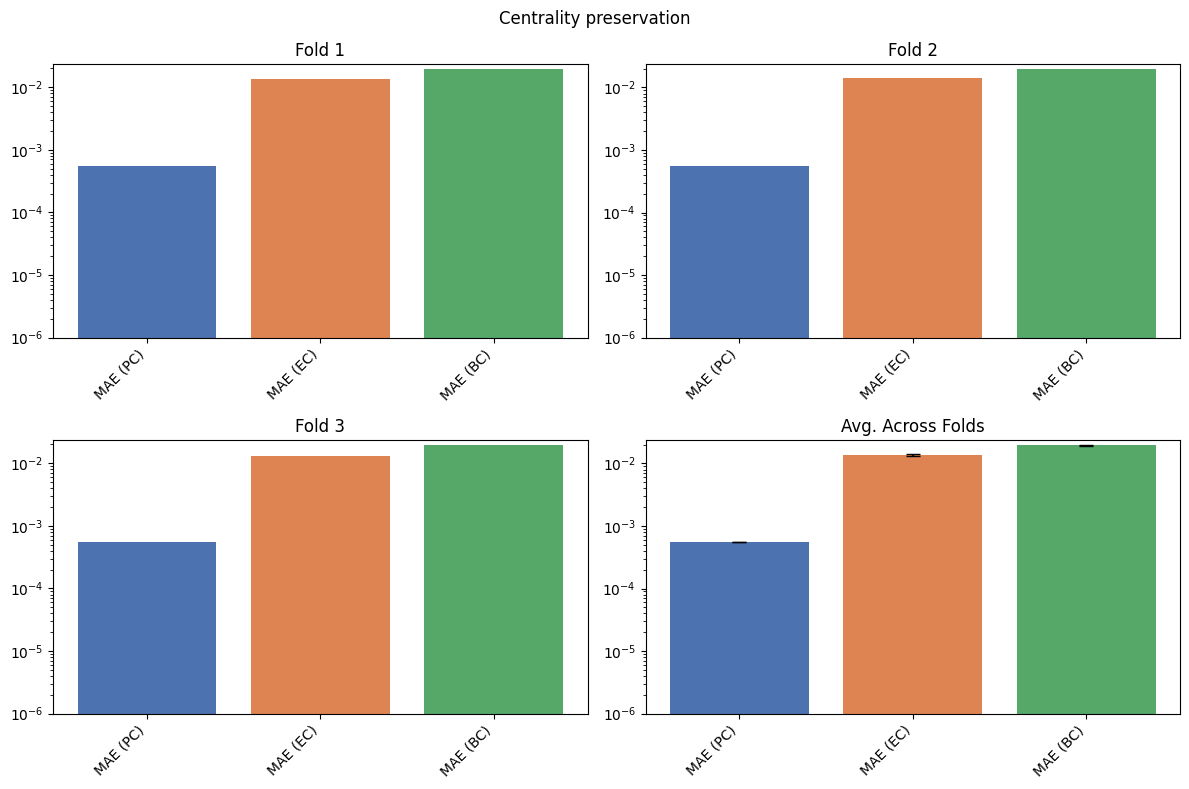

Plotting Structural topology: ['MAE (Strength)', 'MAE (Clustering)']


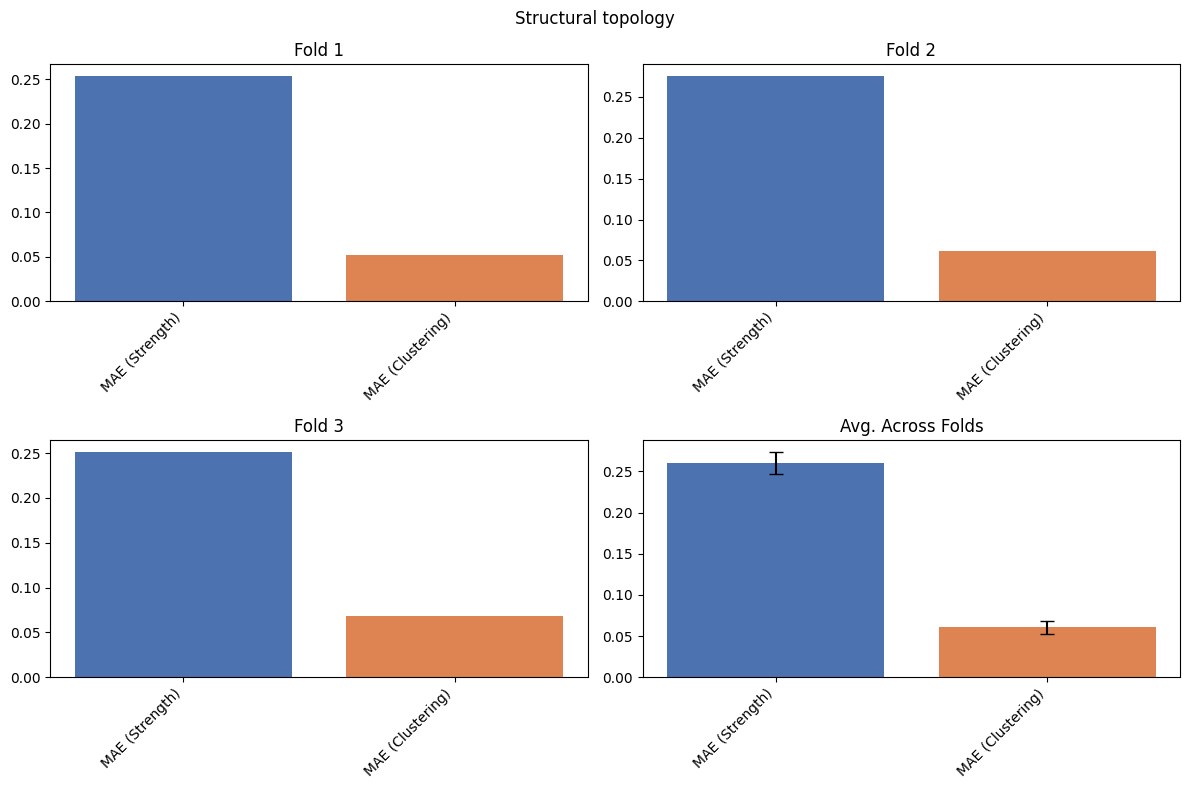


VGAE Baseline | Loading saved CV artifacts from vgae
Loading saved VGAE CV summary from /home/jeet/y4/neurores-gnn/artifacts/comparison/vgae
Plotting Edge prediction: ['MAE', 'PCC', 'JSD']


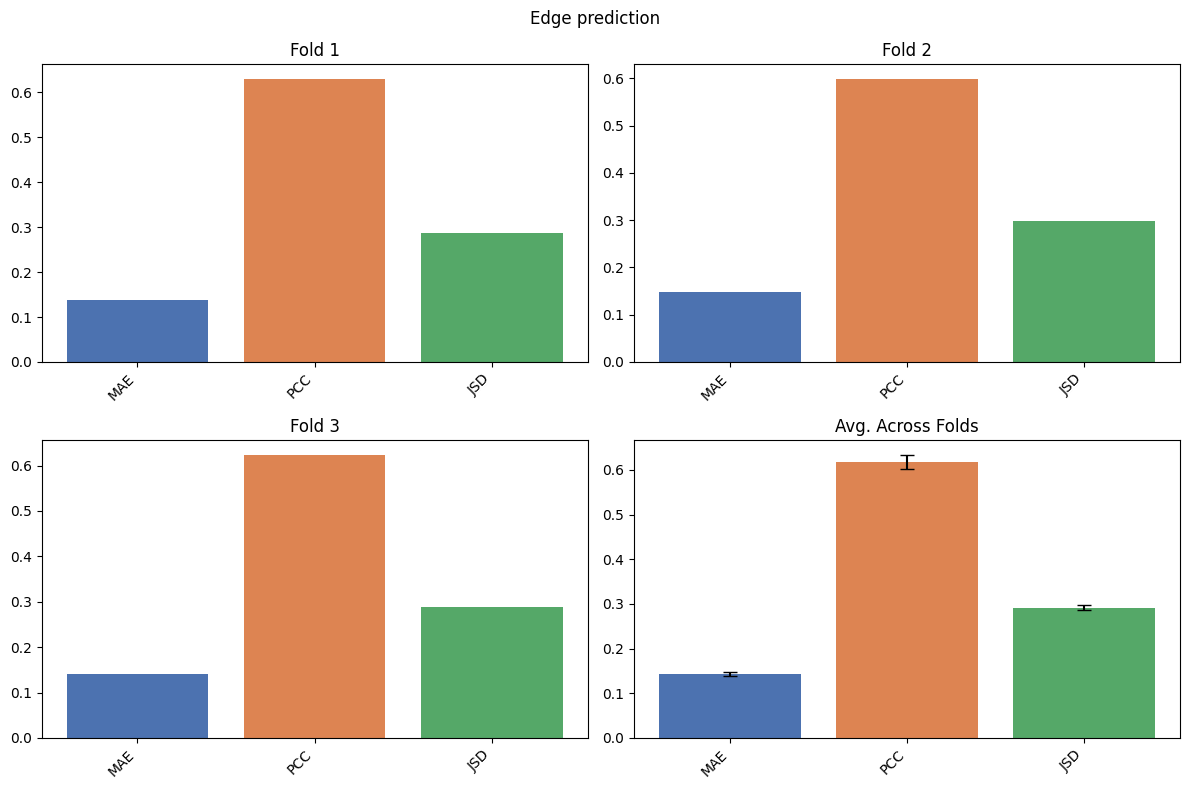

Plotting Centrality preservation: ['MAE (PC)', 'MAE (EC)', 'MAE (BC)']


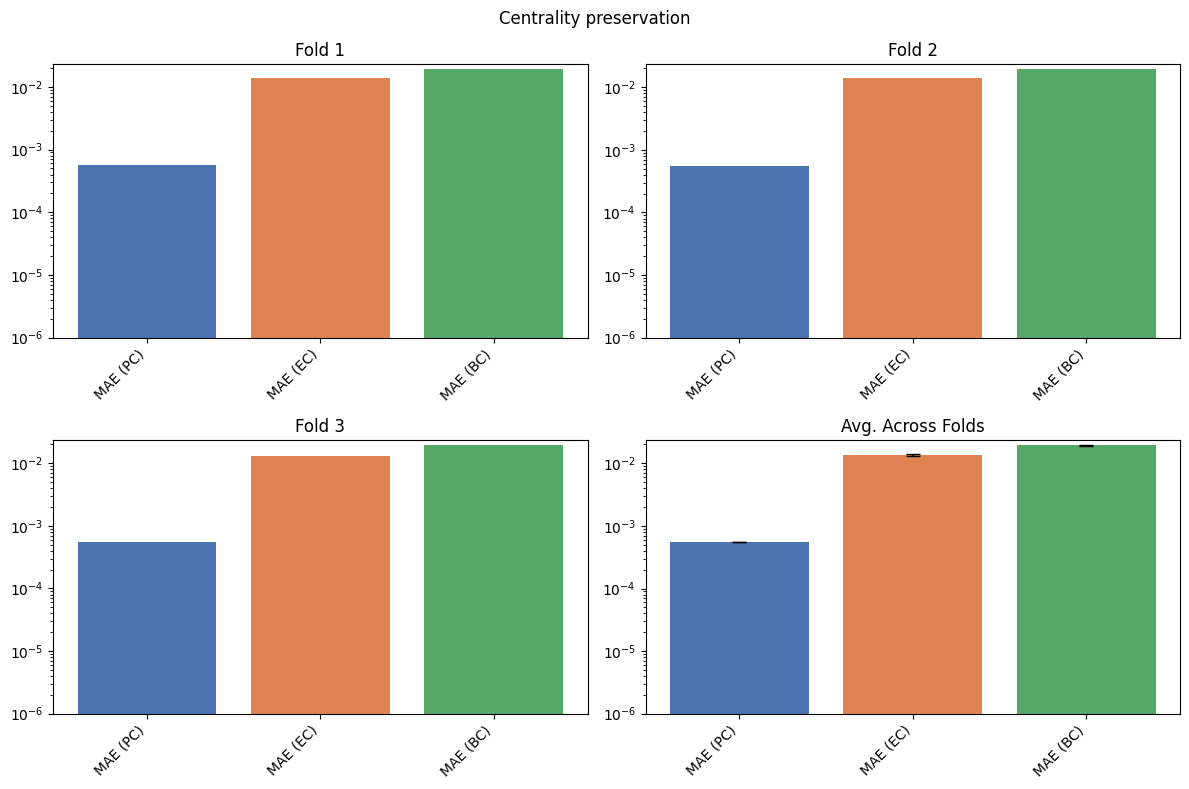

Plotting Structural topology: ['MAE (Strength)', 'MAE (Clustering)']


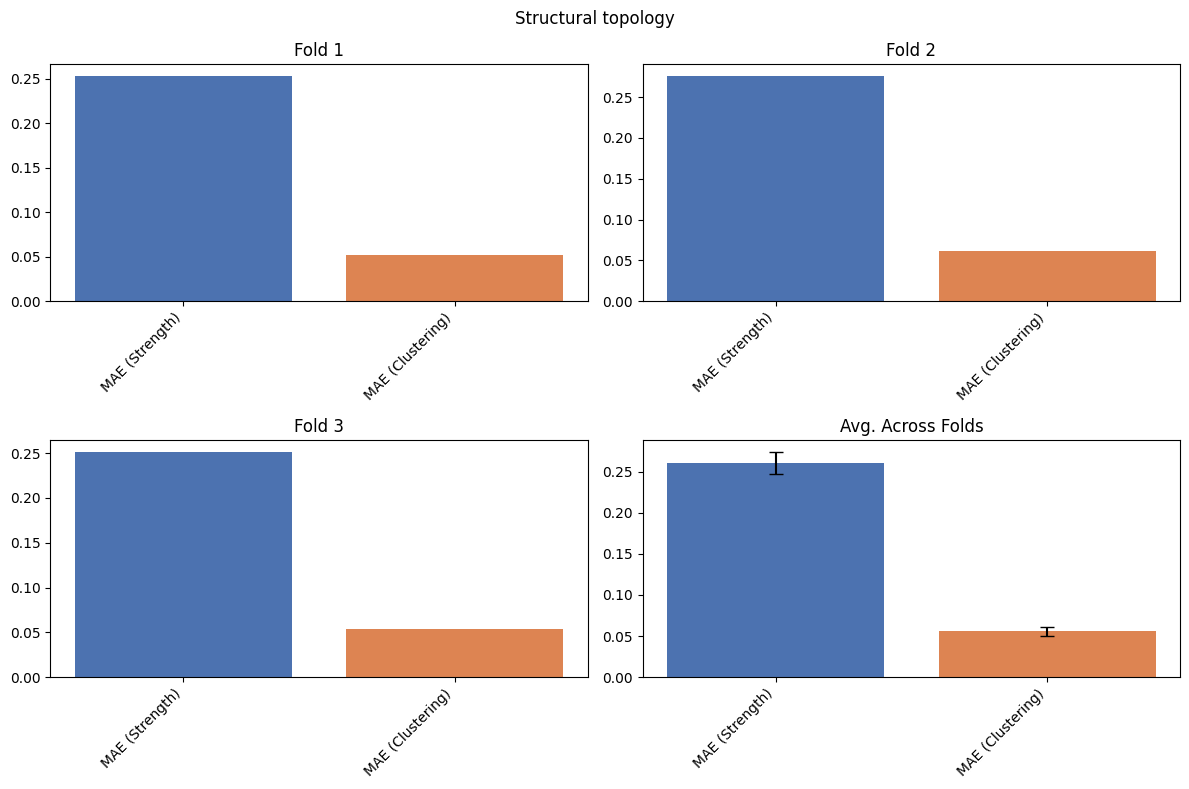

In [5]:
pipeline_outputs = run_main_pipeline(CONFIG)
results = pipeline_outputs['results']
result_v3r = pipeline_outputs['result_v3r']
result_sgc = pipeline_outputs['result_sgc']
result_vgae = pipeline_outputs['result_vgae']

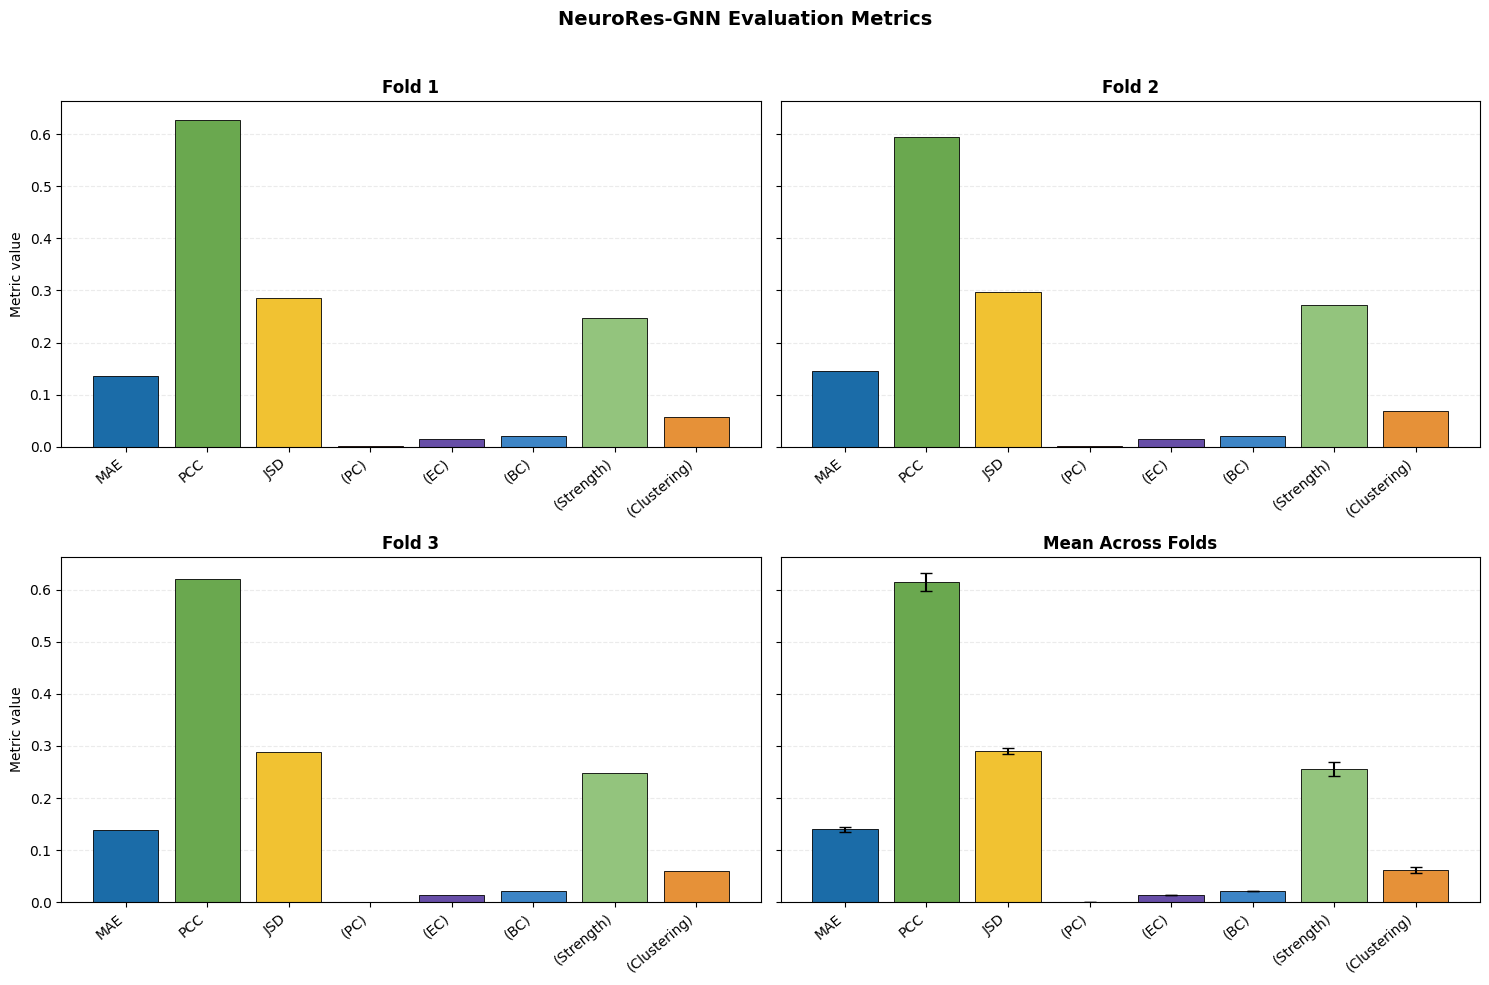

In [11]:
# Plot all 8 metrics for only the v3r_eb_ffnn_aug_light_shrink03 artifact to illustrate the bar plot format (Spec 3.1.2).
# Paper-style layout: one 2x2 figure with Fold 1, Fold 2, Fold 3, and mean across folds.
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'utils').exists() else cwd.parent
sys.path.insert(0, str(repo_root))

from utils.metrics import METRIC_ORDER
from utils.plotting import normalize_strength_in_fold_metrics, summarize_folds

artifact_dir = repo_root / 'artifacts' / 'v3r_eb_ffnn_aug_light_shrink03'
artifact_result = result_v3r if 'result_v3r' in dir() and result_v3r is not None else None
if artifact_result is None:
    cv_path = artifact_dir / 'cv_summary.json'
    if cv_path.exists():
        with open(cv_path, 'r', encoding='utf-8') as f:
            cv_summary = json.load(f)
        artifact_result = {'fold_metrics': [fold['metrics'] for fold in cv_summary['folds']]}
if artifact_result is None:
    raise FileNotFoundError('Could not find saved CV metrics for v3r_eb_ffnn_aug_light_shrink03.')

fold_metrics = normalize_strength_in_fold_metrics(artifact_result['fold_metrics'])
mean_metrics, std_metrics = summarize_folds(fold_metrics)

panel_titles = ['Fold 1', 'Fold 2', 'Fold 3', 'Mean Across Folds']
metric_labels = [label.replace('MAE ', '') for label in METRIC_ORDER]
bar_colors = ['#1b6ca8', '#6aa84f', '#f1c232', '#cc4125', '#674ea7', '#3d85c6', '#93c47d', '#e69138']
x = np.arange(len(METRIC_ORDER))

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < 3:
        values = [fold_metrics[idx][metric] for metric in METRIC_ORDER]
        errors = None
    else:
        values = [mean_metrics[metric] for metric in METRIC_ORDER]
        errors = [std_metrics[metric] for metric in METRIC_ORDER]

    ax.bar(x, values, yerr=errors, capsize=4 if errors is not None else 0, color=bar_colors, edgecolor='black', linewidth=0.6)
    ax.set_title(panel_titles[idx], fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, rotation=40, ha='right')
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)
    if idx in (0, 2):
        ax.set_ylabel('Metric value')

fig.suptitle('NeuroRes-GNN Evaluation Metrics', fontsize=14, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


### Baseline: SGC

Run 3-fold CV with SGC. Saves to artifacts/comparison/sgc. Run only if COMPARE_BASELINES.

In [7]:
if CONFIG.compare_baselines and result_sgc is None:
    comp_dir = repo_root / "artifacts" / "comparison"
    sgc_kw = dict(n_lr=CONFIG.n_lr, n_hr=CONFIG.n_hr, d_model=64, K=2, in_node_feat_dim=2)
    result_sgc = run_3fold_cv_sgc(X_lr_train, Y_hr_train, X_lr_test, model_kwargs=sgc_kw,
        epochs=400, patience=60, lr=8e-4, weight_decay=1e-4, random_state=CONFIG.random_state,
        output_dir=comp_dir / "sgc", plot=True)

### Baseline: VGAE

Run 3-fold CV with VGAE. Saves to artifacts/comparison/vgae. Run only if COMPARE_BASELINES.

In [8]:
if CONFIG.compare_baselines and result_vgae is None:
    comp_dir = repo_root / "artifacts" / "comparison"
    result_vgae = run_3fold_cv_vgae(X_lr_train, Y_hr_train, X_lr_test, epochs=400, patience=60,
        lr=8e-4, weight_decay=1e-4, random_state=CONFIG.random_state, output_dir=comp_dir / "vgae")

### Comparison table (mean MAE)

Run after v3r, SGC, and VGAE cells. Prints mean MAE for each model.

In [9]:
from utils.plotting import summarize_folds

results = {}
if 'result_v3r' in dir() and result_v3r is not None:
    results[f"NeuroRes-GNN ({CONFIG.primary_model})"] = result_v3r
if 'result_sgc' in dir() and result_sgc is not None:
    results['SGC baseline'] = result_sgc
if 'result_vgae' in dir() and result_vgae is not None:
    results['VGAE baseline'] = result_vgae

if results:
    print('--- Comparison (mean MAE) ---')
    for name, res in results.items():
        m, _ = summarize_folds(res['fold_metrics'])
        print(f"{name}: {m['MAE']:.6f}")
else:
    print('Run v3r, SGC, and/or VGAE cells first.')

--- Comparison (mean MAE) ---
NeuroRes-GNN (v3r_eb_ffnn_aug_light): 0.140146
SGC baseline: 0.142331
VGAE baseline: 0.142221


## 8. Scalability Summary

This section reuses saved CV summaries and checkpoints to estimate parameter count, average train time per epoch, and test-time inference latency without retraining the models.

In [10]:
import json
import time
from src.train_dense_gcn import TrainConfig, build_model, compute_lap_pe, predict_vectors


def _fold_y_means(y_train: np.ndarray, seed: int, num_folds: int) -> dict[int, np.ndarray]:
    """Reconstruct fold-wise training means for residual models from saved CV settings."""
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    means = {}
    for fold_id, (tr_idx, _) in enumerate(kf.split(y_train), start=1):
        means[fold_id] = y_train[tr_idx].mean(axis=0).astype(np.float32)
    return means


def summarize_scalability(
    artifact_dirs: list[Path],
    x_test: np.ndarray,
    y_train: np.ndarray,
    device: torch.device = DEVICE,
) -> pd.DataFrame:
    """Build a report-ready scalability table from existing artifacts/checkpoints."""
    rows = []

    for artifact_dir in artifact_dirs:
        cv_path = artifact_dir / 'cv_summary.json'
        if not cv_path.exists():
            print(f'Skipping {artifact_dir}: missing cv_summary.json')
            continue

        with open(cv_path, 'r', encoding='utf-8') as f:
            cv = json.load(f)

        cfg = TrainConfig(**cv['config'])
        cpu_model = build_model(cfg, torch.device('cpu'))
        trainable_params = sum(p.numel() for p in cpu_model.parameters() if p.requires_grad)
        del cpu_model

        fold_records = cv['folds']
        avg_train_sec_per_epoch = float(np.mean([
            r['fold_seconds'] / max(r['best_epoch'], 1)
            for r in fold_records
        ]))
        avg_fold_seconds = float(np.mean([r['fold_seconds'] for r in fold_records]))

        x_test_in = x_test
        if cfg.lap_pe_dim > 0:
            lap_pe_test = compute_lap_pe(x_test, cfg.n_lr, cfg.lap_pe_dim, MatrixVectorizer())
            x_test_in = np.concatenate([x_test, lap_pe_test], axis=1)

        y_mean_by_fold = _fold_y_means(y_train, cfg.seed, cfg.num_folds) if cfg.use_residual else {}
        inference_times = []

        peak_ram_gb = np.nan
        resource_path = artifact_dir / 'resource_summary.json'
        if resource_path.exists():
            with open(resource_path, 'r', encoding='utf-8') as f:
                resource = json.load(f)
            peak_ram_gb = resource.get('peak_ram_gb_rss', np.nan)

        for fold_record in fold_records:
            ckpt_path_str = fold_record.get('checkpoint')
            if not ckpt_path_str:
                continue
            ckpt_path = Path(ckpt_path_str)
            if not ckpt_path.exists():
                continue
            payload = torch.load(ckpt_path, map_location=device)
            model = build_model(cfg, device)
            model.load_state_dict(payload['model'])

            if torch.cuda.is_available() and device.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = predict_vectors(
                model,
                x_test_in,
                device,
                MatrixVectorizer(),
                cfg.batch_size,
                cfg.n_lr,
                y_mean=y_mean_by_fold.get(fold_record['fold']),
                lap_pe_dim=cfg.lap_pe_dim,
            )
            if torch.cuda.is_available() and device.type == 'cuda':
                torch.cuda.synchronize()
            inference_times.append(time.perf_counter() - t0)
            del model

        avg_infer_seconds = float(np.mean(inference_times)) if inference_times else np.nan
        infer_ms_per_subject = (1000.0 * avg_infer_seconds / len(x_test)) if inference_times else np.nan

        rows.append({
            'Artifact': artifact_dir.name,
            'Model': cfg.model_name,
            'Hidden Dim': cfg.hidden_dim,
            'Layers': cfg.num_layers,
            'Trainable Params': trainable_params,
            'Approx Model Size (MB)': round(trainable_params * 4 / (1024 ** 2), 2),
            'Avg Train Time / Epoch (s)': round(avg_train_sec_per_epoch, 3),
            'Avg Fold Train Time (s)': round(avg_fold_seconds, 1),
            'Avg Test Inference Time (s)': None if pd.isna(avg_infer_seconds) else round(avg_infer_seconds, 4),
            'Avg Test Inference / Subject (ms)': None if pd.isna(infer_ms_per_subject) else round(infer_ms_per_subject, 3),
            'Peak RAM RSS (GB)': None if pd.isna(peak_ram_gb) else round(float(peak_ram_gb), 3),
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['Hidden Dim', 'Layers', 'Artifact']).reset_index(drop=True)
    return df


# Choose completed CV artifact dirs that illustrate scaling with hidden size / depth.
SCALABILITY_ARTIFACTS = [
    repo_root / 'artifacts' / 'dense_gcn_v2',
    repo_root / 'artifacts' / 'dense_gcn_v3',
    repo_root / 'artifacts' / 'v3r_cv_full',
    repo_root / 'artifacts' / 'v3r_eb_ffnn_aug_light_shrink03',
    repo_root / 'artifacts' / 'dense_gat_v4',
]

scalability_df = summarize_scalability(
    artifact_dirs=[p for p in SCALABILITY_ARTIFACTS if p.exists()],
    x_test=X_lr_test,
    y_train=Y_hr_train,
    device=DEVICE,
)

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'
print(f'Inference device: {DEVICE} | Hardware: {gpu_name}')
display(scalability_df)


Inference device: cuda | Hardware: NVIDIA GeForce RTX 4080 Laptop GPU


,Artifact,Model,Hidden Dim,Layers,Trainable Params,Approx Model Size (MB),Avg Train Time / Epoch (s),Avg Fold Train Time (s),Avg Test Inference Time (s),Avg Test Inference / Subject (ms),Peak RAM RSS (GB)
0,dense_gcn_v2,dense_stp,192,3,1125005,4.29,1.175,33.6,NaN,NaN,1.634
1,dense_gcn_v3,dense_gcn,192,3,1148174,4.38,7.484,54.6,NaN,NaN,1.818
2,v3r_cv_full,dense_gcn,192,3,1148174,4.38,1.100,438.8,NaN,NaN,1.606
3,v3r_eb_ffnn_aug_light_shrink03,dense_gcn,192,3,1148174,4.38,0.847,243.5,0.8463,7.557,1.887
4,dense_gat_v4,dense_gat,192,4,1558032,5.94,0.962,276.2,NaN,NaN,1.921
